In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

In [3]:
sns.set()

Load Data

In [4]:
data = datasets.load_iris()

Goal is to use attributes of the flower to predict the species of the flower. Specifically whether the flower is Setoa, Versicolor or Virginica. This will be done using the sepal length and width and petal length and width.

# Make Pandas Data Frame

In [5]:
df = pd.DataFrame(data['data'], columns=data["feature_names"])
df["target"] = data["target"]
df["target_name"] = df["target"].map({0:"setosa",1:"versicolor",2:"virginica"})

In [6]:
# Train test split, setting aside 25% of data randomly to test later
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.25)

# Basic Descriptive Stats

In [7]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# EDA Pairplots

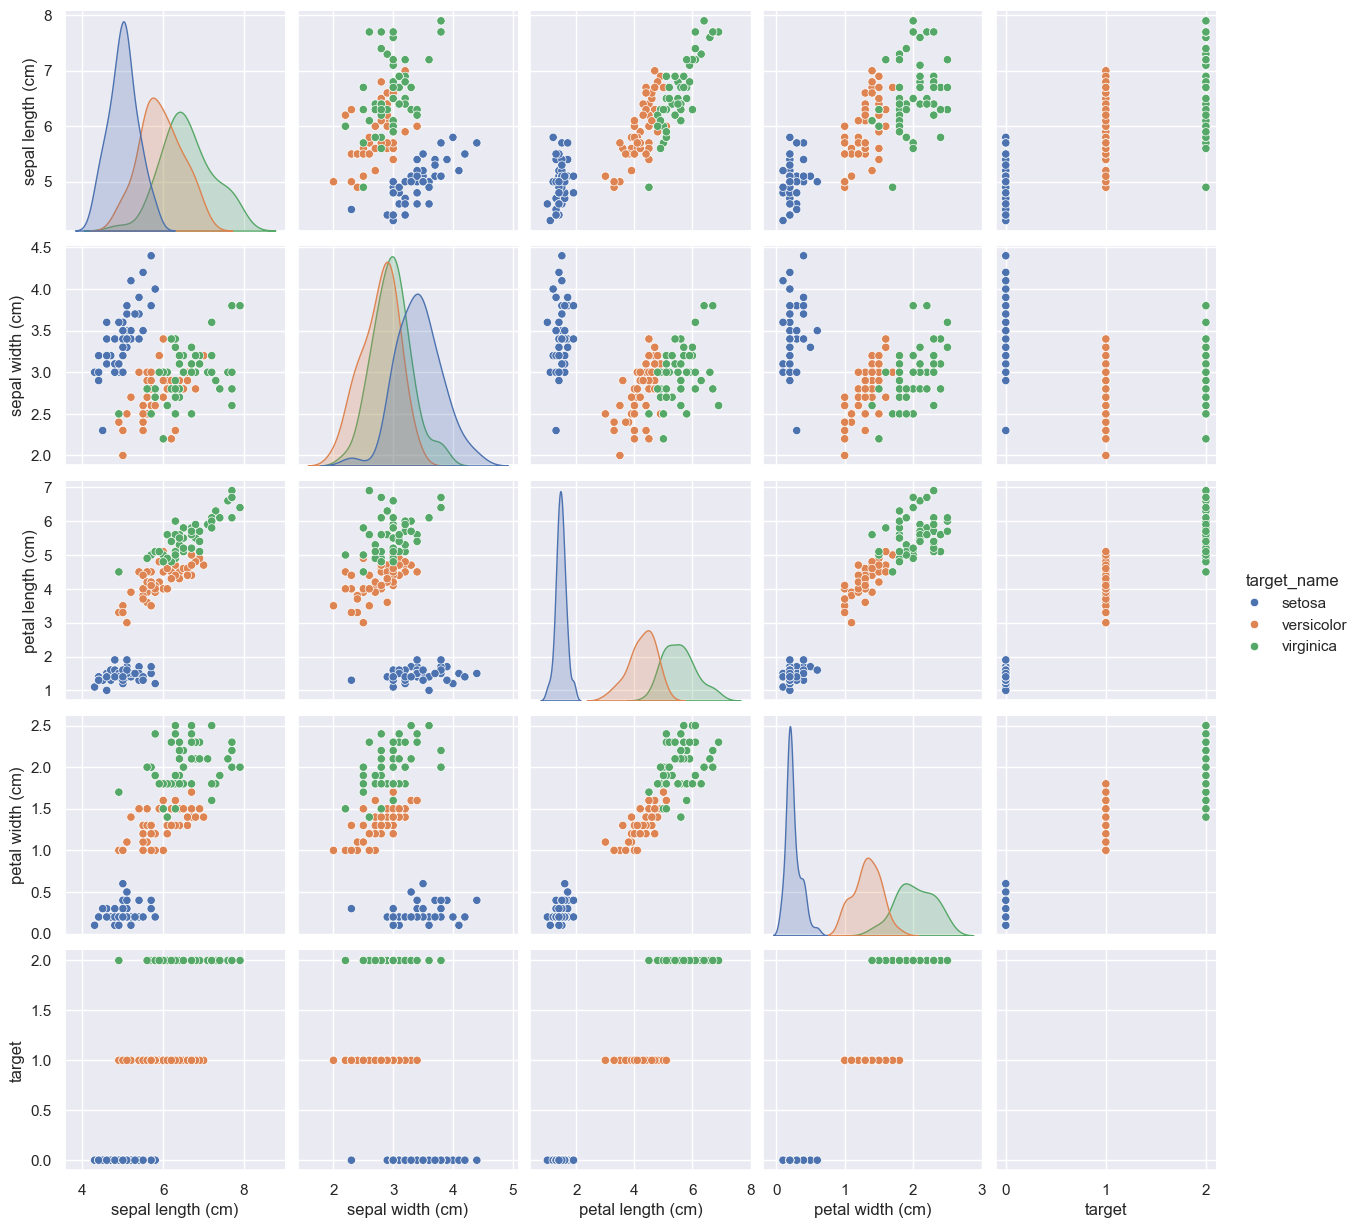

In [8]:
sns.pairplot(df, hue="target_name")

In [9]:
x_train = df_train.drop(columns=["target","target_name"]).values
y_train = df_train["target"].values

# What is baseline?

What is the simplest model? We could randomly guess and get a 33% accuracy or choose the same target for each flower and get a 33%

Model should be atleast 33% accurate.

# ToDo add to readme

# Simple Manual model

In [10]:
def single_feature_prediction(petal_length):
    if petal_length < 2.5:
        return 0
    elif petal_length < 4.5:
        return 1
    else: 
        return 2

In [11]:
manual_y_predictions =np.array([single_feature_prediction(val) for val in x_train[:,2]])

In [12]:
manual_model_accuracy = np.mean(manual_y_predictions == y_train)

In [13]:
print(f"manual model accuracty: {manual_model_accuracy * 100:.2f}%")

manual model accuracty: 88.39%


# Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=200)


### Evaluating with validation sets

In [15]:
xt, xv, yt, yv = train_test_split(x_train, y_train, test_size=0.25)

In [16]:
model.fit(xt,yt)

LogisticRegression(max_iter=200)

In [17]:
score =model.score(xv,yv) # don't want to evaluate model on the same data as training
print(f"manual model accuracty: {score * 100:.2f}%")

manual model accuracty: 92.86%


# Cross Validation
process of iteratively leaving out parts of the data to test on so that each part is used as part of the test

In [18]:
from sklearn.model_selection import cross_val_score, cross_val_predict

In [19]:
model = LogisticRegression(max_iter=200)

In [20]:
accuracies =cross_val_score(model, x_train, y_train, cv=5, scoring="accuracy") # default = 5

In [21]:
np.mean(accuracies)

0.9549407114624506

# Locating Misclassification Points

In [22]:
y_pred = cross_val_predict(model, x_train, y_train, cv=5)

In [23]:
predicted_correctly_mask = y_pred == y_train

In [24]:
x_train[~predicted_correctly_mask]

array([[6. , 2.2, 5. , 1.5],
       [4.9, 2.5, 4.5, 1.7],
       [6.7, 3. , 5. , 1.7],
       [5.9, 3.2, 4.8, 1.8],
       [6. , 2.7, 5.1, 1.6]])

In [25]:
df_predictions = df_train.copy()

In [26]:
df_predictions["correct_prediction"] = predicted_correctly_mask

In [27]:
df_predictions["prediction"] = y_pred

In [28]:
df_predictions["prediction_label"] = df_predictions["prediction"].map({0:"setosa",1:"versicolor",2:"virginica"})

In [37]:
def plot_incorrect_predictions(df_predictions, x_axis, y_axis):
    fig,axs = plt.subplots(2,2,figsize=(10,10))
    axs = axs.flatten()
    sns.scatterplot(x=x_axis,y=y_axis, hue="prediction_label", data=df_predictions, ax=axs[0])
    sns.scatterplot(x=x_axis,y=y_axis, hue="target_name", data=df_predictions, ax=axs[1])
    sns.scatterplot(x=x_axis,y=y_axis, hue="correct_prediction", data=df_predictions, ax=axs[2])
    axs[3].set_visible(False)
    plt.show()

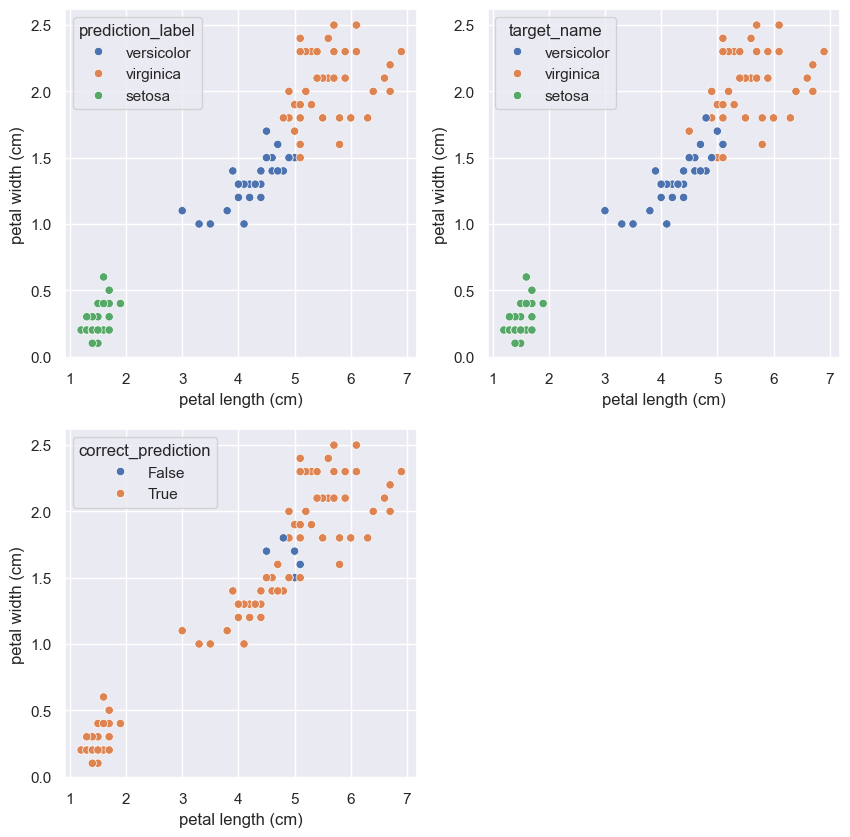

In [38]:
plot_incorrect_predictions(df_predictions,"petal length (cm)", "petal width (cm)")

# Model Tuning

In [50]:
for reg_param in (0.1, 0.3, 0.9, 1, 1.3, 1.9, 2):
    model = LogisticRegression(max_iter=200, C=reg_param)
    accuracies = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')
    print(f"Accuracy: {np.mean(accuracies) * 100:.2f}%")

Accuracy: 91.03%
Accuracy: 94.58%
Accuracy: 95.49%
Accuracy: 95.49%
Accuracy: 95.49%
Accuracy: 94.62%
Accuracy: 94.62%


# Final Model

In [51]:
model = LogisticRegression(max_iter=200, C=2)

# testing on test set

In [54]:
x_test = df_test.drop(columns=["target", "target_name"]).values
y_test = df_test["target"].values

### Train final model

In [55]:
model.fit(x_train, y_train)

LogisticRegression(C=2, max_iter=200)

In [59]:
y_test_pred = model.predict(x_test)
test_set_correctly_classified = y_test_pred == y_test
test_set_accuracy = np.mean(test_set_correctly_classified)

In [61]:
print(f"test set accuracy: {test_set_accuracy* 100:.2f}")

test set accuracy: 100.00


In [69]:
not_predicted_correctly = ~test_set_correctly_classified
df_predictions_test = df_test.copy()
df_predictions_test["correct_prediction"] = test_set_correctly_classified
df_predictions_test["prediction_label"] = y_test_pred

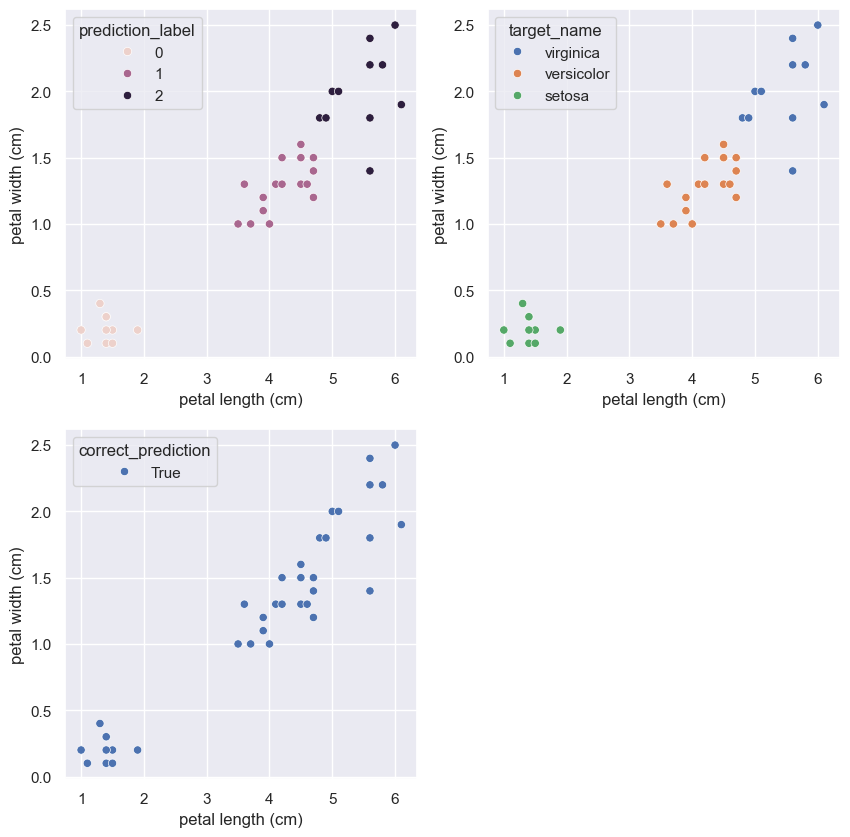

In [70]:
plot_incorrect_predictions(df_predictions_test, x_axis="petal length (cm)", y_axis="petal width (cm)")

# In Conclusion
I achieved an accuracy of 100% on the test data set using a logistic regression using the parameters, C=2 and 200 iterations.

In [71]:
model?

In [74]:
model.fit(x_train,y_train)

LogisticRegression(C=2, max_iter=200)